# Exporation of mhd_ch4_formatted_v1.csv 

df_mhd_ch4_raw : raw data

df_mhd_ch4_v1: one-hot flags

df_mhd_ch4_v2: a copy of df_mhd_ch4_v1

df_mhd_ch4_v3:drop the feature contains almost all are nan values

df_mhd_ch4_drop: drop extreme values from psamp and pflow


In [ ]:
import seaborn as sns
sns.set_theme(style='darkgrid')

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

# read data files
df_mhd_ch4_raw = pd.read_csv("../data/processed/mhd_ch4_formatted_v1.csv")
df_mhd_ch4_raw.head(20)


/tmp/ipykernel_25164/4231044995.py:6: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mhd_ch4_raw = pd.read_csv("../data/processed/mhd_ch4_formatted_v1.csv")


,date,time,type,sample,standard,port,ht,tmod,tamb,temp,...,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,NaN,NaN,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN


In [4]:
df_mhd_ch4_raw.iloc[[-1]]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,...,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
817954,260518,81300,std,J-286,J-286,3,0,40.0,22.23,NaN,...,NaN,NaN,NaN,14.873,NaN,2015.923,NaN,NaN,A,NaN


In [5]:
df_mhd_ch4_raw.iloc[[11123]]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,...,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
11123,940802,114700,std,G-028,G-028,1,0,40.0,23.89,NaN,...,1671.33,1672.89,1671.33,2.264,NaN,1672.724,NaN,NaN,NaN,NaN


In [6]:
print(df_mhd_ch4_raw['ploop']-(df_mhd_ch4_raw['ploop'].isnull()))

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
817950   NaN
817951   NaN
817952   NaN
817953   NaN
817954   NaN
Name: ploop, Length: 817955, dtype: float64


In [7]:
df_mhd_ch4_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 42 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             817955 non-null  int64  
 1   time             817955 non-null  int64  
 2   type             817954 non-null  object 
 3   sample           817955 non-null  object 
 4   standard         817955 non-null  object 
 5   port             817955 non-null  int64  
 6   ht               817955 non-null  int64  
 7   tmod             705671 non-null  float64
 8   tamb             705671 non-null  float64
 9   temp             0 non-null       float64
 10  pflow            815553 non-null  float64
 11  psamp            815626 non-null  float64
 12  ploop            0 non-null       float64
 13  pamb             815551 non-null  float64
 14  rt               816365 non-null  float64
 15  w                816365 non-null  float64
 16  CH4_ht.1         816365 non-null  floa

 9   temp             1 non-null       float64
12  ploop            1 non-null       float64
 41  CH4_flag_p       0 non-null       float64

 ----------
 almost all Nan
 maybe no use for training ml model

In [8]:
string_list = ['type', 'sample', 'standard', 'CH4_flag_ht', 'CH4_flag_a', 'CH4_flag']
for i in string_list:
    print(f"{i} values including:,{df_mhd_ch4_raw[i].value_counts()}", "\n")

type values including:,type
std        414114
air        372609
tank        15952
cal560       2616
cal660       2609
cal860       2607
cal960       2603
cal1060      2595
cal           987
labair        653
blank         521
cal150         12
tank100         6
cal225          6
cal30           6
cal120          6
cal60           6
cal180          6
cal300          6
cal90           6
cal45           4
cal15           3
cal135          3
cal75           3
cal105          3
cal200          3
cal165          3
cal250          3
cal500          3
Name: count, dtype: int64 

sample values including:,sample
10m       335171
9m         34964
J-273      12205
J-254      11469
J-231      11315
           ...  
990619         1
990631         1
990628         1
990633         1
H-313          1
Name: count, Length: 515, dtype: int64 

standard values including:,standard
J-273       24266
J-254       22463
J-231       22202
J-197       21469
J-223       21298
J-206       21233
J-144       21048


/tmp/ipykernel_25164/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_25164/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_25164/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_25164/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_25164/1842129789.py:9: FutureWarn

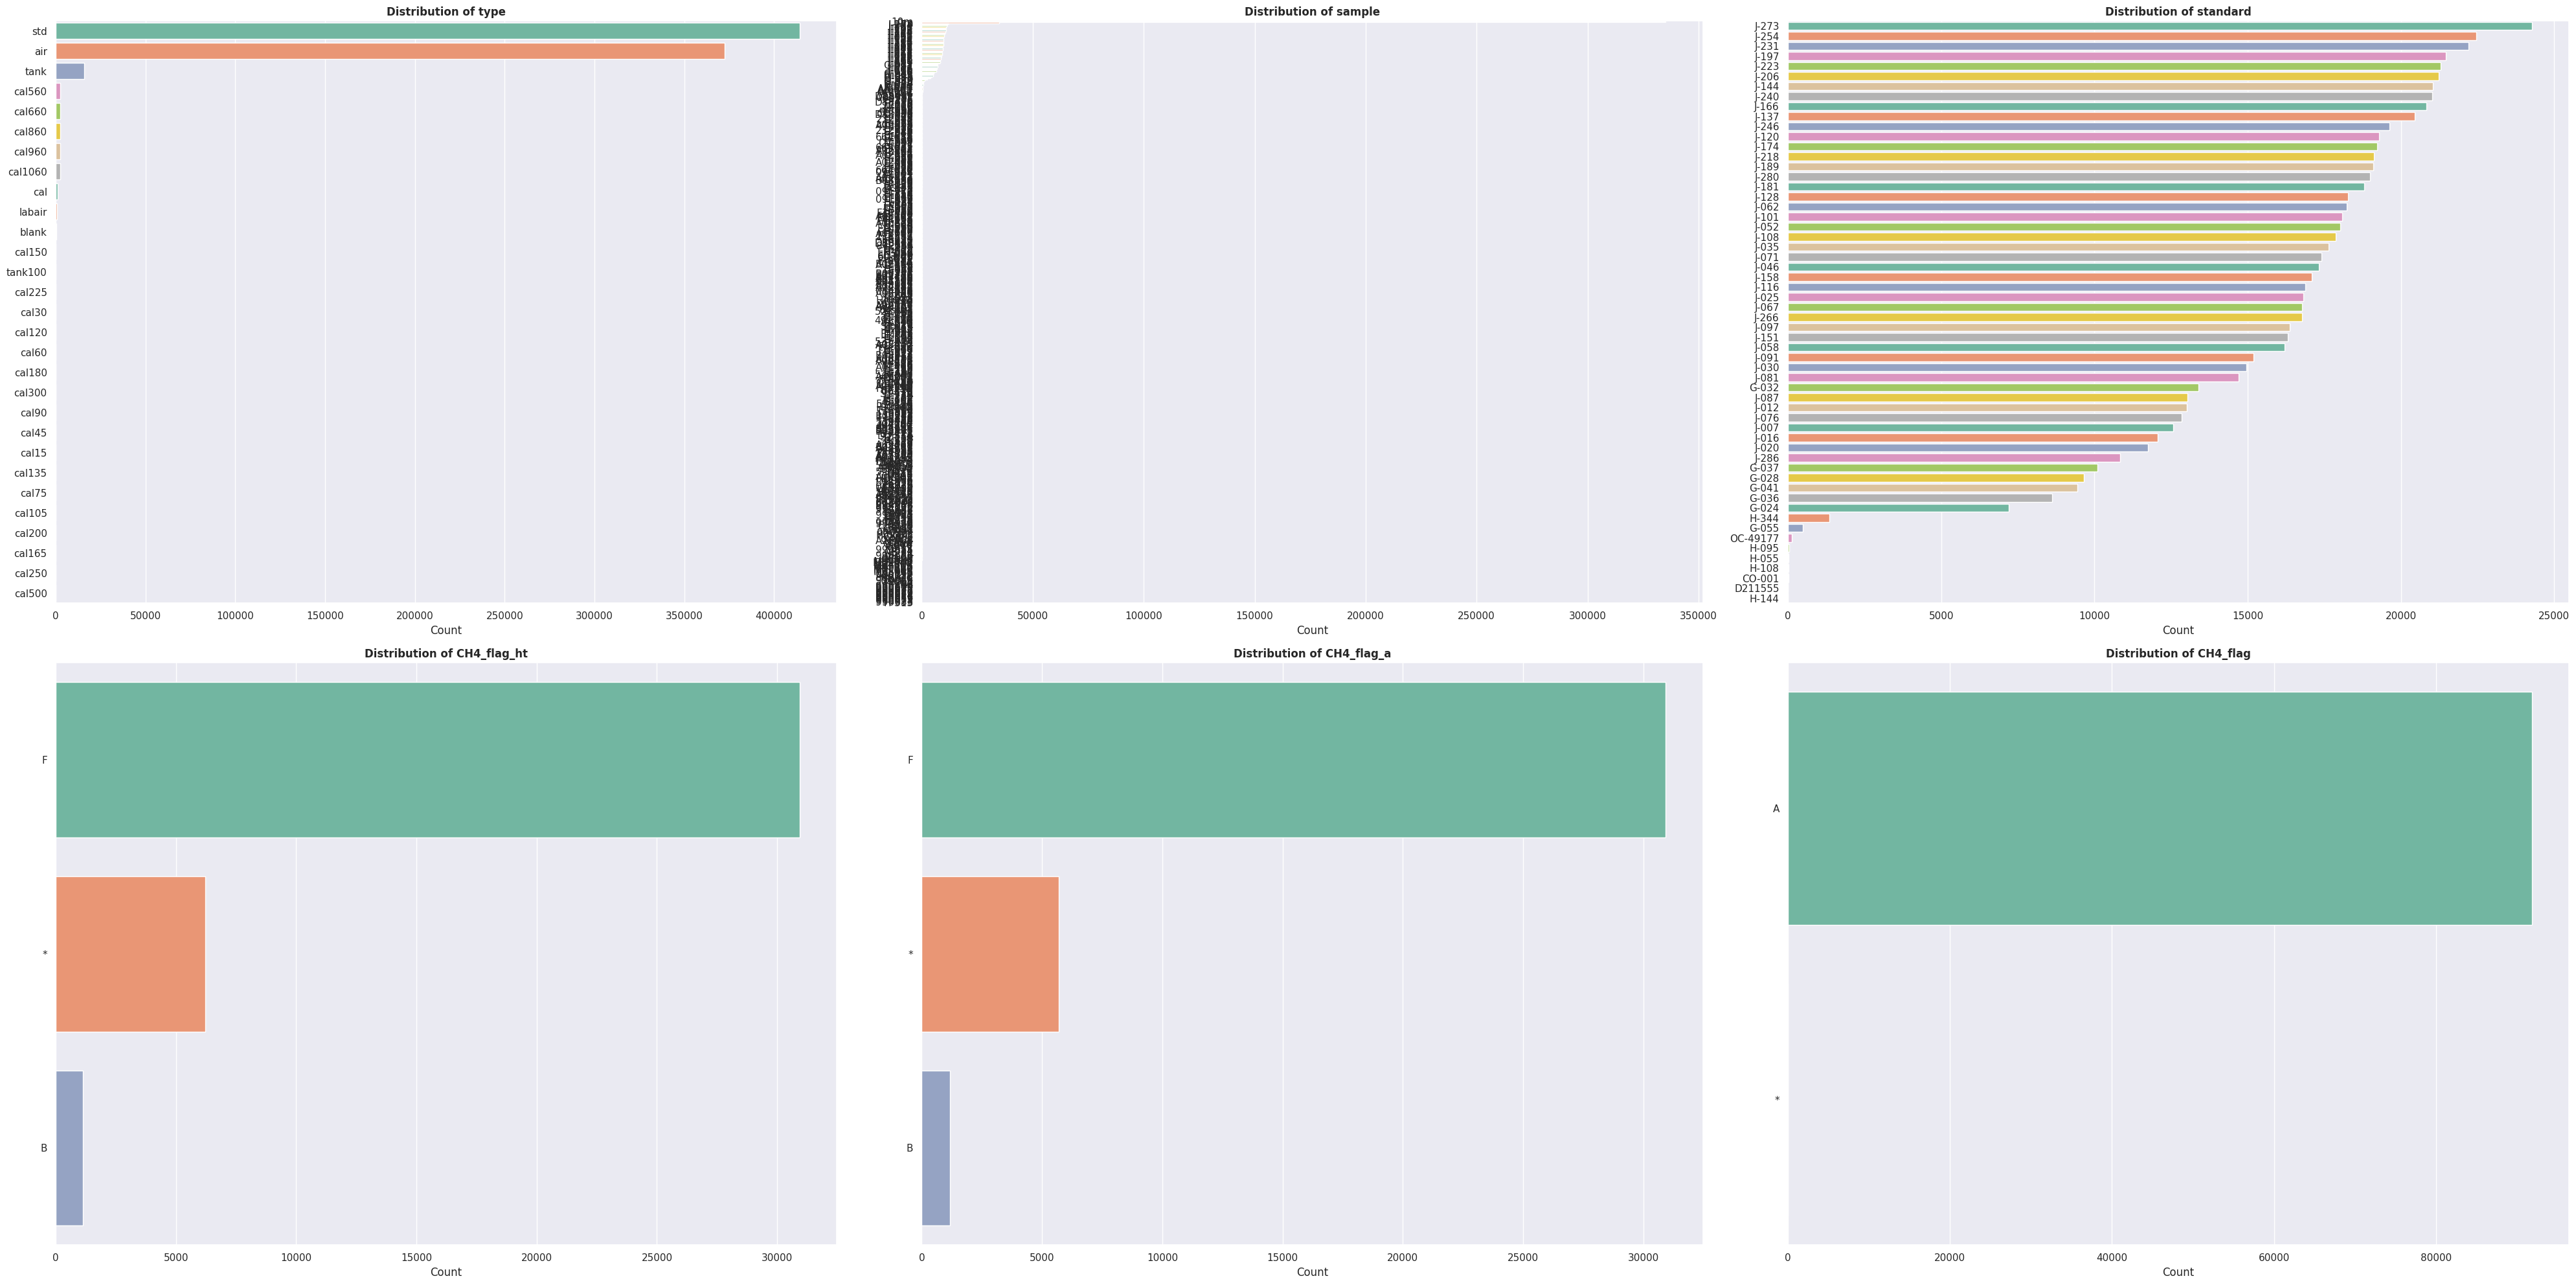

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2,3, figsize=(40, 20))

axes = axes.flatten()

for i, col in enumerate(string_list):
    if col in df_mhd_ch4_raw.columns:
        sns.countplot(
            data=df_mhd_ch4_raw,
            y=col,
            ax=axes[i],
            order = df_mhd_ch4_raw[col].value_counts().index,
            palette='Set2'
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel('')

    else:
        axes[i].set_title(f'{col} (Not Found)')

plt.tight_layout()
plt.show()

The distribution plot of sample is too narrow
-> make it bigger to explore it

/tmp/ipykernel_25164/1873865919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


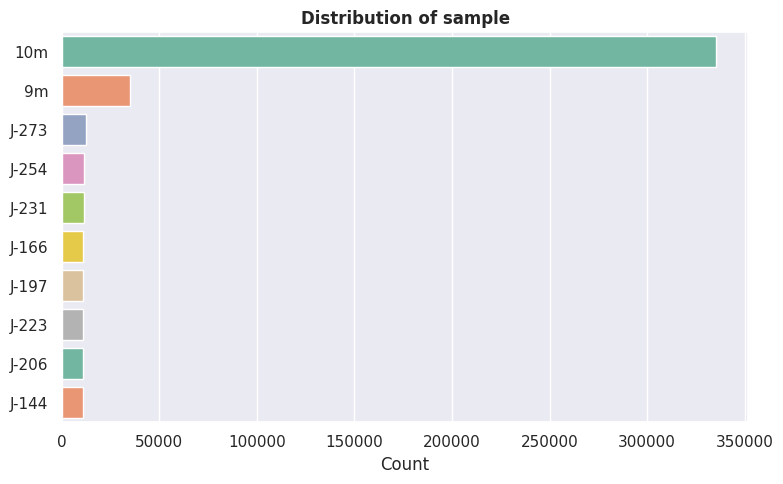

In [10]:
fig, axes = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=df_mhd_ch4_raw,
    y='sample',
    order = df_mhd_ch4_raw['sample'].value_counts().index[:10],
    palette='Set2'
)
axes.set_title(f'Distribution of sample', fontsize=12, fontweight='bold')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

====== 0523 ends =======

=============== 0525 starts==============

0526 feature engineering
create new feature: label( show whether good or bad data)

In [11]:
df_mhd_ch4_v1 =df_mhd_ch4_raw.copy()

In [12]:
# convert nan values into " "(space)-> means good values
mapping={" ":0, 
          "x":1, 
          "*":1,
          "F":1, 
          "B":1, 
          "A":1
        }
df_mhd_ch4_v1 ["CH4_flag"] = df_mhd_ch4_v1 ["CH4_flag"].fillna(" ")
df_mhd_ch4_v1 ["CH4_flag_ht"] = df_mhd_ch4_v1 ["CH4_flag_ht"].fillna(" ")
df_mhd_ch4_v1 ["CH4_flag_a"] = df_mhd_ch4_v1 ["CH4_flag_a"].fillna(" ")

In [13]:
# convert flag to 0/1
df_mhd_ch4_v1 ["CH4_flag_ht"] = df_mhd_ch4_v1 ["CH4_flag_ht"].map(mapping)
df_mhd_ch4_v1 ["CH4_flag_a"] = df_mhd_ch4_v1 ["CH4_flag_a"].map(mapping)


In [14]:
df_mhd_ch4_v1 ['label'] = ((df_mhd_ch4_v1 ["CH4_flag_ht"]==1) | (df_mhd_ch4_v1 ["CH4_flag_ht"]==1)).astype(int)
df_mhd_ch4_v1 ['label']

0         1
1         1
2         1
3         0
4         1
         ..
817950    0
817951    0
817952    0
817953    1
817954    0
Name: label, Length: 817955, dtype: int64

In [15]:
df_mhd_ch4_v1["CH4_flag"] 

0          
1          
2          
3          
4          
         ..
817950    A
817951    A
817952    A
817953    A
817954    A
Name: CH4_flag, Length: 817955, dtype: object

In [16]:
df_mhd_ch4_v2 = df_mhd_ch4_v1.copy()

df_mhd_ch4_v2

In [17]:
pd.set_option('display.max_columns', None)
df_mhd_ch4_v2.iloc[[185]]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
185,940219,102700,cal1060,G-024,G-024,1,0,40.01,23.16,NaN,846.8,1058.3,NaN,751.2,95.2,7.51,205489.0,1651923.0,1.0,82.6,130.2,30872.0,30727.0,0.92736,1.00177,0.92736,1.3073,1.4122,1.0901,0.92736,1.00177,0.92736,1569.54,1695.49,1692.49,3.18,NaN,1692.489,0,0,,NaN,0


In [18]:
df_mhd_ch4_v2.iloc[[-1]]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
817954,260518,81300,std,J-286,J-286,3,0,40.0,22.23,NaN,813.3,752.09,NaN,752.0,82.0,5.46,204547.0,1177596.0,0.43,73.0,115.2,75876.0,68601.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.873,NaN,2015.923,0,0,A,NaN,0


df_mhd_ch4[''].corr()

 0526 dataset checked no error 

In [19]:
df_mhd_ch4_v2.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,0,0,,NaN,0
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,NaN,1


In [20]:
df_mhd_ch4_v2.isna().sum().sort_values(ascending=False)

temp               817955
CH4_flag_p         817955
ploop              817955
CH4_std_rep        471914
tmod               112284
tamb               112284
CH4_C               59835
CH4_Rl              58674
CH4_R               58674
CH4_C_ht            52743
CH4_Rl_ht           51247
CH4_norm_a          51247
CH4_norm_w          51247
CH4_R_ht            51247
CH4_norm_ht         51247
CH4_C_a             50993
CH4_Rl_a            49492
CH4_R_a             49492
CH4_std_stdev       21816
pamb                 2404
pflow                2402
psamp                2329
CH4_start_time       1590
w                    1590
CH4_ht.1             1590
CH4_area             1590
CH4_end_level        1590
rt                   1590
CH4_end_time         1590
CH4_start_level      1590
CH4_skew             1590
type                    1
time                    0
date                    0
ht                      0
sample                  0
standard                0
port                    0
CH4_Cstd    

define which features sould quite( too much nan)

In [21]:
cols_to_drop=['temp','CH4_flag_p','ploop','CH4_flag' ]
df_mhd_ch4_v3 = df_mhd_ch4_v2.drop(columns=cols_to_drop)

df_mhd_ch4_v3

In [22]:
df_mhd_ch4_v3.isna().sum().sort_values(ascending=False)

CH4_std_rep        471914
tmod               112284
tamb               112284
CH4_C               59835
CH4_R               58674
CH4_Rl              58674
CH4_C_ht            52743
CH4_norm_ht         51247
CH4_norm_w          51247
CH4_norm_a          51247
CH4_R_ht            51247
CH4_Rl_ht           51247
CH4_C_a             50993
CH4_Rl_a            49492
CH4_R_a             49492
CH4_std_stdev       21816
pamb                 2404
pflow                2402
psamp                2329
CH4_skew             1590
CH4_area             1590
w                    1590
CH4_start_level      1590
rt                   1590
CH4_end_level        1590
CH4_start_time       1590
CH4_end_time         1590
CH4_ht.1             1590
type                    1
time                    0
date                    0
ht                      0
port                    0
standard                0
sample                  0
CH4_Cstd                0
CH4_flag_ht             0
CH4_flag_a              0
label       

In [23]:
df_mhd_ch4_v3['type'].value_counts()

type
std        414114
air        372609
tank        15952
cal560       2616
cal660       2609
cal860       2607
cal960       2603
cal1060      2595
cal           987
labair        653
blank         521
cal150         12
tank100         6
cal225          6
cal30           6
cal120          6
cal60           6
cal180          6
cal300          6
cal90           6
cal45           4
cal15           3
cal135          3
cal75           3
cal105          3
cal200          3
cal165          3
cal250          3
cal500          3
Name: count, dtype: int64

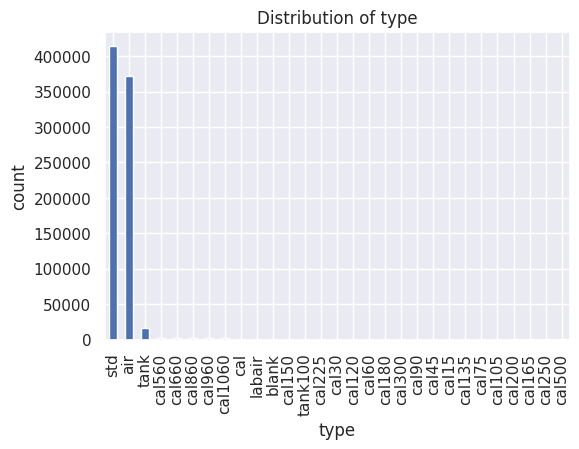

In [24]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['type'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribution of type")
plt.xlabel('type')
plt.ylabel('count')
plt.show()

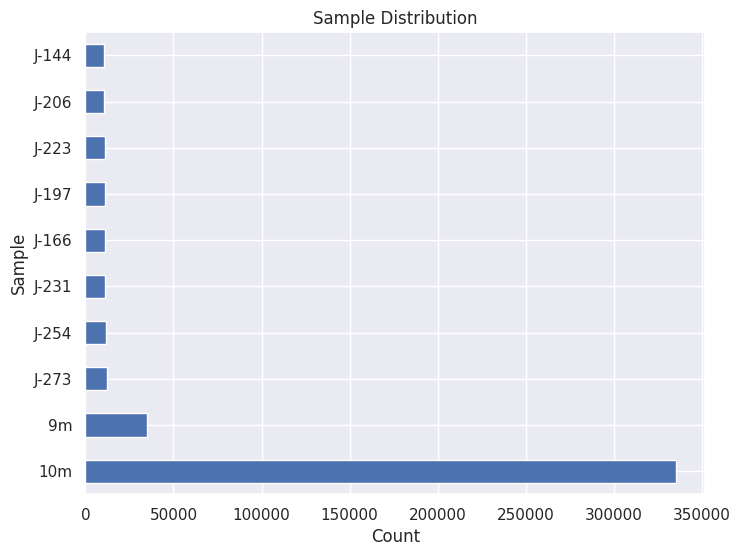

In [25]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['sample'].value_counts().head(10).plot(
    kind='barh',
    figsize=(8,6)
)
plt.title("Sample Distribution")
plt.xlabel('Count')
plt.ylabel('Sample')
plt.show()
# too many -> only show first 10
#===================
# 10m, 9m -> air
# other-> std, cal

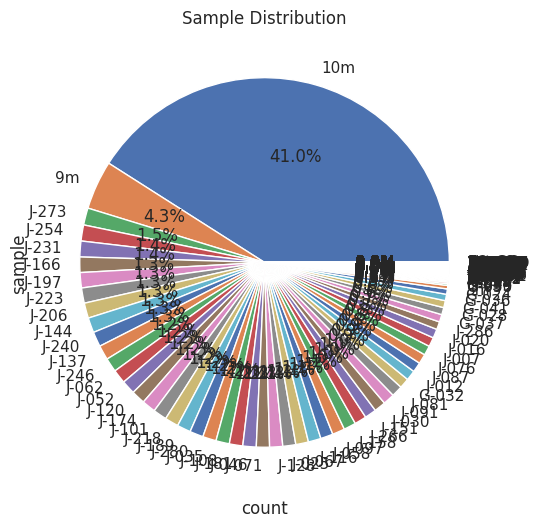

In [26]:
df_mhd_ch4_v3['sample'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Sample Distribution')
plt.xlabel('count')
plt.ylabel('sample')
plt.show()

The pie chart show that the 10m and 9m accounts most data
-> 10m, 9m means -> air

In [27]:
pd.set_option('display.max_rows', None)
df_mhd_ch4_v3['sample'].value_counts()

sample
10m       335171
9m         34964
J-273      12205
J-254      11469
J-231      11315
J-166      11009
J-197      10937
J-223      10877
J-206      10854
J-144      10735
J-240      10665
J-137      10426
J-246      10029
J-062       9962
J-052       9915
J-120       9850
J-174       9825
J-101       9771
J-218       9768
J-189       9760
J-280       9692
J-035       9662
J-108       9609
J-181       9603
J-046       9550
J-071       9416
J-128       9336
J-025       9260
J-067       9078
J-116       9078
J-058       8931
J-097       8871
J-158       8699
J-266       8552
J-151       8323
J-030       8229
J-091       8217
J-081       7916
G-032       7182
J-012       7166
J-087       7064
J-076       6944
J-007       6790
J-016       6613
J-020       6449
J-286       5573
G-037       5375
G-028       5112
G-041       5014
G-036       4571
G-024       3811
3m          2465
G-050       1181
G-055       1132
H-344        726
H-054        719
H-055        605
labair       534
H-095  

type ->  std and correponding sample

In [28]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='std', 'sample'].unique()

array(['G-024', 'G-028', 'G-032', 'CO-001', 'G-036', 'G-037', 'G-041',
       'J-007', 'J-012', 'J-016', 'J-020', 'J-025', 'J-030', 'J-035',
       'J-046', 'J-052', 'J-058', 'J-062', 'J-067', 'J-071', 'J-076',
       'J-081', 'J-087', 'J-091', 'J-097', 'J-101', '-49177', 'J-108',
       'J-116', 'H-108', 'J-120', 'H-144', 'J-128', 'J-137', 'J-144',
       'G-055', 'J-151', 'J-158', 'J-166', 'J-174', 'J-181', 'J-189',
       'J-197', 'H-095', 'J-206', 'H-344', 'J-218', 'J-223', 'J-231',
       'J-240', 'J-246', 'J-254', 'J-266', 'J-273', 'H-055', '211555',
       'J-280', 'J-286'], dtype=object)

type ->  air and correponding sample

In [29]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='air', 'sample'].unique()

array(['10m', '158E-p', 'Sib1_4', '3m', '9m'], dtype=object)

type ->  tank and correponding sample

In [30]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='tank', 'sample'].unique()


array(['-49177', 'G-024', 'S-003', 'G-032', 'S-004', 'H-005', 'H-004',
       'H-006D', 'H-006', 'MRF-S', 'MRF-D', 'H-003', 'CO-001', '005557',
       'G-036', '49177D', 'O-001D', 'G-037', 'H-007', '60-H09', '60-H05',
       'FD-005', 'H-008D', 'H-008', 'G-041', 'CO1', 'J-007', 'H-009',
       'M-001', 'M-002', 'H-009D', 'H-010', 'H-011', 'J-012', 'M-005',
       '.Leeds', 'J-016', 'H-012', 'Bris1', 'G-050', 'G-055', 'H-013',
       'H-014', 'M-006', 'B-003', 'M-007', 'J-020', 'H-015', 'BRW1',
       '064959', 'HD-007', '-007-6', '-007-4', '-007-3', '-007-2',
       'J-025', 'H-016', 'A01469', 'A01467', 'A01477', 'M-008', 'G-064',
       'H-017', 'H-018', 'M-009', 'H-019', 'H-020', 'J-030', 'A03255',
       'A03233', 'A03229', 'A03220', 'A02964', '990635', '990624',
       '990621', '990629', '990630', '990622', '990625', '990620',
       '990634', '990632', '990631', '990619', '990636', '990628',
       '990626', '990627', '990633', '990623', 'FC-001', 'H-021', 'H-022',
       'J-035'

Distribution of port

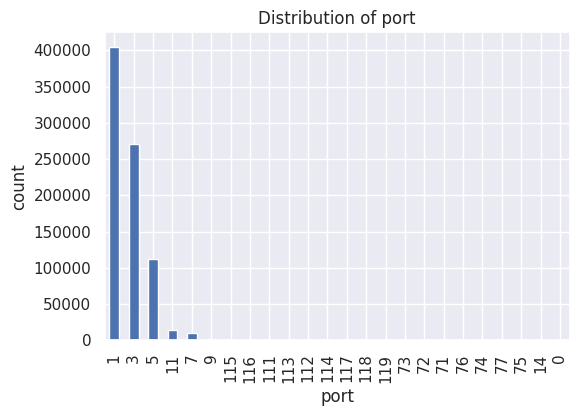

In [31]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['port'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribution of port")
plt.xlabel('port')
plt.ylabel('count')
plt.show()

Port 1, 3, 5 are the most used ones

# instrument states

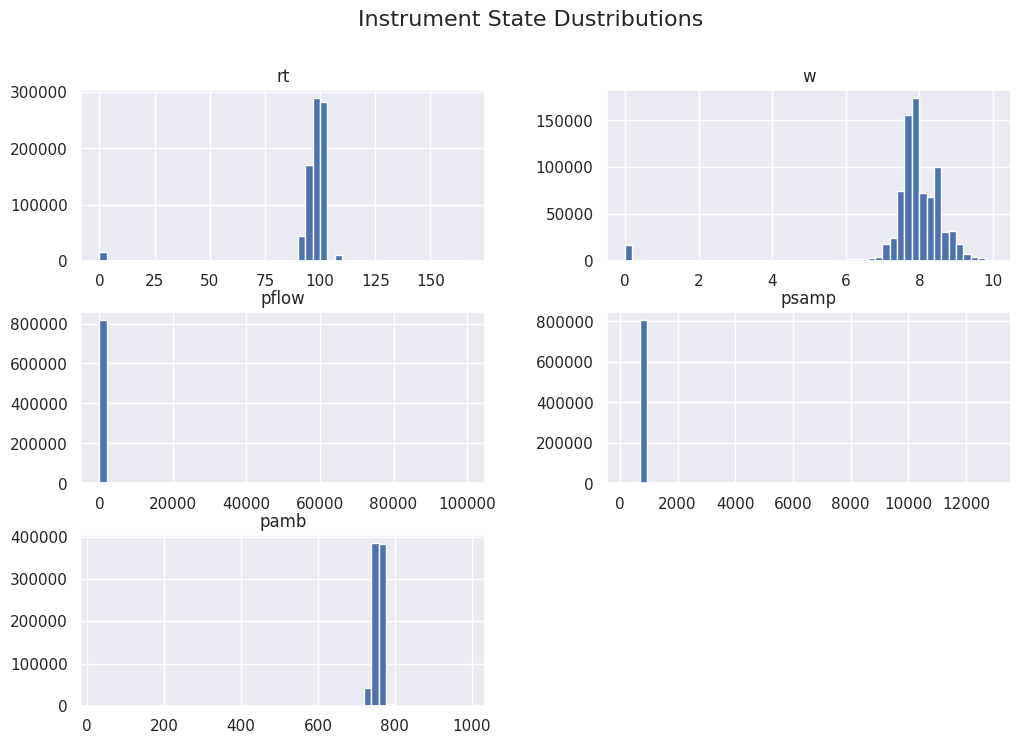

In [32]:
import matplotlib.pyplot as plt
cols = ['rt', 'w', 'pflow', 'psamp', 'pamb']

df_mhd_ch4_v3[cols].hist(figsize=(12,8), bins=50)
plt.suptitle("Instrument State Dustributions", fontsize=16)
plt.show()

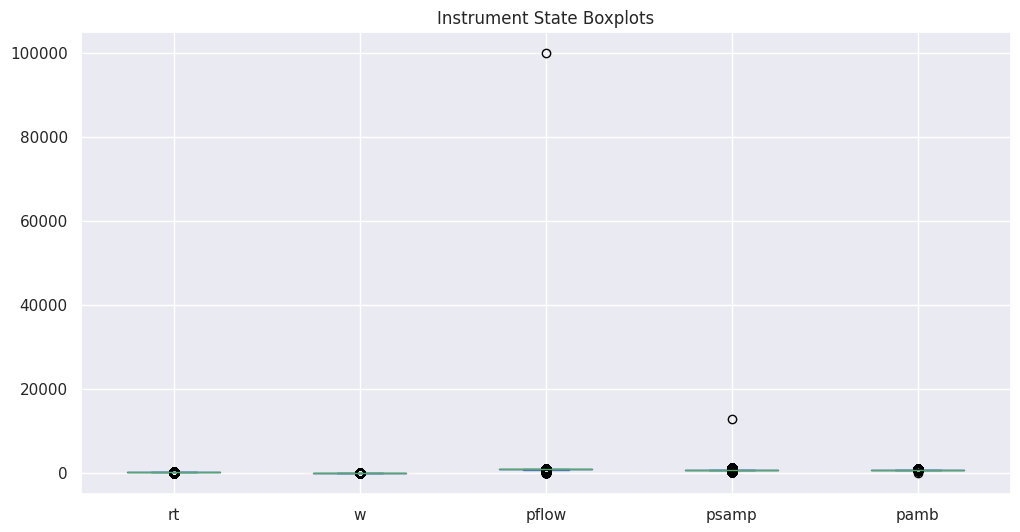

In [33]:
df_mhd_ch4_v3[cols].plot(kind='box', figsize=(12,6))
plt.title("Instrument State Boxplots")
plt.show()

pflow has a data point at nearly 100000, psamp has one at 10000?
try to move the 100000 one

In [34]:
df_mhd_ch4_v3[df_mhd_ch4_v3['pflow']>=8000]

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label
128952,990406,32600,std,J-030,J-030,1,0,40.0,20.27,99999.0,NaN,NaN,101.6,7.62,143978.0,1179415.0,1.08,89.2,136.2,20326.0,20306.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.736,NaN,1839.437,1,1,1


In [35]:
df_mhd_ch4_raw[df_mhd_ch4_raw['pflow']>=8000]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
128952,990406,32600,std,J-030,J-030,1,0,40.0,20.27,NaN,99999.0,NaN,NaN,NaN,101.6,7.62,143978.0,1179415.0,1.08,89.2,136.2,20326.0,20306.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.736,NaN,1839.437,F,F,NaN,NaN


In [36]:
df_mhd_ch4_raw[df_mhd_ch4_raw['psamp']>=10000]

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
323309,61209,50400,std,J-097,J-097,1,0,40.0,22.64,NaN,810.3,12922.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.355,NaN,1861.378,F,F,NaN,NaN


flag_ht and flag_a were all bad
-> back check -> F flag

the psamp 12922-> flag h and flag a -> F

In [37]:
df_mhd_ch4_v3[cols].describe()

,rt,w,pflow,psamp,pamb
count,816365.000000,816365.000000,815553.000000,815626.000000,815551.000000
mean,96.537053,7.828751,811.954561,757.492715,756.593960
std,14.293443,1.310069,112.196125,30.281787,9.839729
min,0.000000,0.000000,0.000000,182.710000,31.900000
25%,96.400000,7.690000,801.100000,750.570000,750.700000
50%,98.600000,7.870000,809.700000,757.590000,757.600000
75%,100.600000,8.370000,818.900000,763.550000,763.400000
max,166.600000,9.990000,99999.000000,12922.000000,987.500000


rt, w, pflow min are 0


In [38]:
df_mhd_ch4_raw[df_mhd_ch4_raw['rt']==0].head(20)
# head(1000) can see tank

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
10,940216,202300,air,10m,G-024,3,10,40.00,33.17,NaN,846.1,759.83,NaN,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
11,940216,204300,air,10m,G-024,3,10,40.00,33.05,NaN,846.3,759.91,NaN,759.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN


In [39]:
(df_mhd_ch4_raw['rt']==0).sum()

np.int64(16699)

rt == 0 -> most F flag

but if it's 'cal' type -> Nan

tank is also ->nan

In [40]:
df_mhd_ch4_raw[df_mhd_ch4_raw['w']==0].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
10,940216,202300,air,10m,G-024,3,10,40.00,33.17,NaN,846.1,759.83,NaN,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
11,940216,204300,air,10m,G-024,3,10,40.00,33.05,NaN,846.3,759.91,NaN,759.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN


In [41]:
(df_mhd_ch4_raw['w']==0).sum()

np.int64(16725)

w==0 -> 16725 data

rt = 0 -> 16699 data

==========

explore the data where rt = 0 but w is not 0

In [42]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['w']==0) & (df_mhd_ch4_raw['rt']!=0)].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
2090,940322,93400,air,10m,G-024,3,10,40.01,25.09,NaN,836.9,754.15,NaN,NaN,90.2,0.0,0.0,0.0,0.76,83.6,90.8,28394.0,44771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.190,NaN,1692.489,NaN,NaN,NaN,NaN
135153,990706,112700,std,J-030,J-030,1,0,40.00,22.28,NaN,817.3,760.05,NaN,760.1,89.2,0.0,0.0,0.0,1.32,87.8,110.6,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.260,NaN,1839.437,F,F,NaN,NaN
218278,21015,162000,air,10m,J-062,3,10,40.00,20.66,NaN,812.0,752.05,NaN,752.1,105.4,0.0,0.0,0.0,1.44,104.0,126.8,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.654,NaN,1849.264,F,F,NaN,NaN
311839,60619,174000,std,J-091,J-091,1,0,40.00,20.30,NaN,809.1,756.68,NaN,756.8,98.6,0.0,0.0,0.0,1.25,93.0,123.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.441,NaN,1851.219,F,F,A,NaN
517178,140618,120400,std,J-166,J-166,3,0,40.00,24.62,NaN,808.6,769.71,NaN,769.6,87.4,0.0,0.0,0.0,0.51,81.6,108.2,17233.0,10466.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.236,NaN,1883.393,F,F,NaN,NaN
601021,170930,112300,std,J-206,J-206,11,0,40.00,18.03,NaN,802.8,755.22,NaN,755.0,99.0,0.0,154611.0,1734697.0,1.00,81.0,146.4,32451.0,33496.0,1.00123,0.99736,1.00123,1.0013,0.9974,0.9954,1.00123,0.99736,1.00123,1948.40,1940.88,1948.40,1.675,NaN,1946.007,NaN,NaN,NaN,NaN
601146,171002,54300,labair,labair,J-206,9,0,40.00,17.51,NaN,207.9,254.09,NaN,755.3,97.8,0.0,153417.0,1728162.0,1.16,80.4,145.8,32992.0,34350.0,2.96066,2.90195,2.96066,0.9965,0.9768,0.9758,2.96066,2.90195,2.96066,5761.47,5647.22,5761.47,1.682,NaN,1946.007,NaN,NaN,NaN,NaN
604180,171113,234500,air,10m,J-206,1,10,40.00,20.03,NaN,780.3,762.69,NaN,762.8,98.8,0.0,154006.0,1723995.0,1.01,80.8,146.0,35419.0,36567.0,0.98362,0.98675,0.98362,0.9837,0.9868,1.0032,0.98362,0.98675,0.98362,1914.13,1920.22,1914.13,1.840,1.810,1946.007,NaN,NaN,NaN,NaN
604183,171114,10500,air,10m,J-206,1,10,40.00,20.17,NaN,780.9,762.89,NaN,762.8,98.8,0.0,154217.0,1725930.0,1.03,81.0,145.8,35361.0,36557.0,0.98396,0.98635,0.98396,0.9840,0.9864,1.0025,0.98396,0.98635,0.98396,1914.79,1919.44,1914.79,1.785,1.756,1946.007,NaN,NaN,NaN,NaN
604198,171114,60500,std,J-206,J-206,11,0,40.00,20.13,NaN,809.3,762.11,NaN,762.0,98.8,0.0,156727.0,1755617.0,1.03,80.8,146.0,35955.0,37166.0,1.00089,1.00456,1.00089,1.0009,1.0045,1.0025,1.00089,1.00456,1.00089,1947.73,1954.87,1947.73,1.797,NaN,1946.007,NaN,NaN,NaN,NaN


In [43]:
((df_mhd_ch4_raw['w']==0) & (df_mhd_ch4_raw['rt']!=0)).sum()

np.int64(26)

In [44]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['w']==0) & (df_mhd_ch4_raw['rt']!=0)]


,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
2090,940322,93400,air,10m,G-024,3,10,40.01,25.09,NaN,836.9,754.15,NaN,NaN,90.2,0.0,0.0,0.0,0.76,83.6,90.8,28394.0,44771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.190,NaN,1692.489,NaN,NaN,NaN,NaN
135153,990706,112700,std,J-030,J-030,1,0,40.00,22.28,NaN,817.3,760.05,NaN,760.1,89.2,0.0,0.0,0.0,1.32,87.8,110.6,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.260,NaN,1839.437,F,F,NaN,NaN
218278,21015,162000,air,10m,J-062,3,10,40.00,20.66,NaN,812.0,752.05,NaN,752.1,105.4,0.0,0.0,0.0,1.44,104.0,126.8,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.654,NaN,1849.264,F,F,NaN,NaN
311839,60619,174000,std,J-091,J-091,1,0,40.00,20.30,NaN,809.1,756.68,NaN,756.8,98.6,0.0,0.0,0.0,1.25,93.0,123.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.441,NaN,1851.219,F,F,A,NaN
517178,140618,120400,std,J-166,J-166,3,0,40.00,24.62,NaN,808.6,769.71,NaN,769.6,87.4,0.0,0.0,0.0,0.51,81.6,108.2,17233.0,10466.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.236,NaN,1883.393,F,F,NaN,NaN
601021,170930,112300,std,J-206,J-206,11,0,40.00,18.03,NaN,802.8,755.22,NaN,755.0,99.0,0.0,154611.0,1734697.0,1.00,81.0,146.4,32451.0,33496.0,1.00123,0.99736,1.00123,1.0013,0.9974,0.9954,1.00123,0.99736,1.00123,1948.40,1940.88,1948.40,1.675,NaN,1946.007,NaN,NaN,NaN,NaN
601146,171002,54300,labair,labair,J-206,9,0,40.00,17.51,NaN,207.9,254.09,NaN,755.3,97.8,0.0,153417.0,1728162.0,1.16,80.4,145.8,32992.0,34350.0,2.96066,2.90195,2.96066,0.9965,0.9768,0.9758,2.96066,2.90195,2.96066,5761.47,5647.22,5761.47,1.682,NaN,1946.007,NaN,NaN,NaN,NaN
604180,171113,234500,air,10m,J-206,1,10,40.00,20.03,NaN,780.3,762.69,NaN,762.8,98.8,0.0,154006.0,1723995.0,1.01,80.8,146.0,35419.0,36567.0,0.98362,0.98675,0.98362,0.9837,0.9868,1.0032,0.98362,0.98675,0.98362,1914.13,1920.22,1914.13,1.840,1.810,1946.007,NaN,NaN,NaN,NaN
604183,171114,10500,air,10m,J-206,1,10,40.00,20.17,NaN,780.9,762.89,NaN,762.8,98.8,0.0,154217.0,1725930.0,1.03,81.0,145.8,35361.0,36557.0,0.98396,0.98635,0.98396,0.9840,0.9864,1.0025,0.98396,0.98635,0.98396,1914.79,1919.44,1914.79,1.785,1.756,1946.007,NaN,NaN,NaN,NaN
604198,171114,60500,std,J-206,J-206,11,0,40.00,20.13,NaN,809.3,762.11,NaN,762.0,98.8,0.0,156727.0,1755617.0,1.03,80.8,146.0,35955.0,37166.0,1.00089,1.00456,1.00089,1.0009,1.0045,1.0025,1.00089,1.00456,1.00089,1947.73,1954.87,1947.73,1.797,NaN,1946.007,NaN,NaN,NaN,NaN


In [45]:
df_mhd_ch4_raw[df_mhd_ch4_raw['pflow']==0].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
776630,241008,55600,tank,H-055,J-273,115,0,40.0,18.44,NaN,0.0,739.63,NaN,739.3,98.8,7.82,153228.0,1328790.0,1.04,85.4,136.8,22380.0,22542.0,0.93,0.93006,0.93006,0.9305,0.9306,1.0007,0.93,0.93006,0.93006,1857.28,1857.4,1857.4,3.172,NaN,1997.08,NaN,NaN,A,NaN


**Summary of w and rt**

one of them is zero means a potentially error

make them as labels?

# Explore instrument states by labels

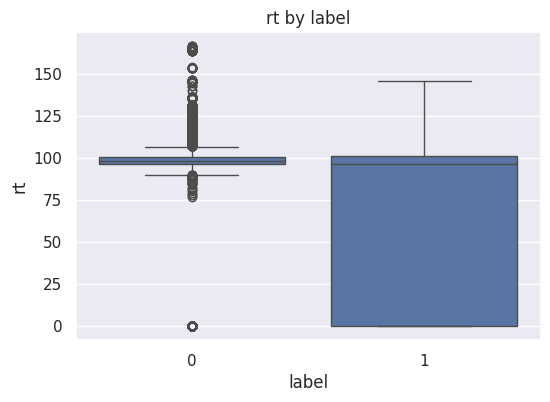

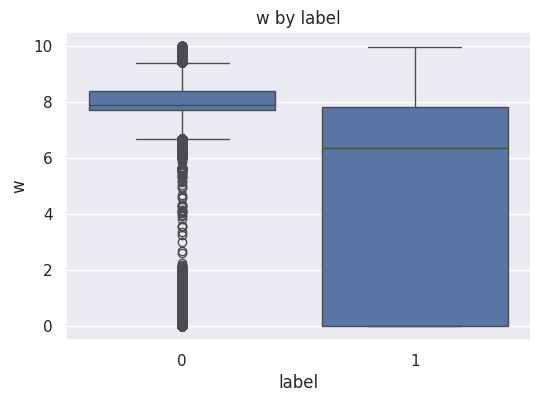

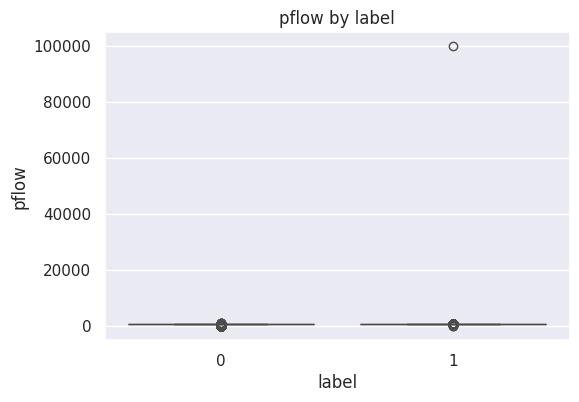

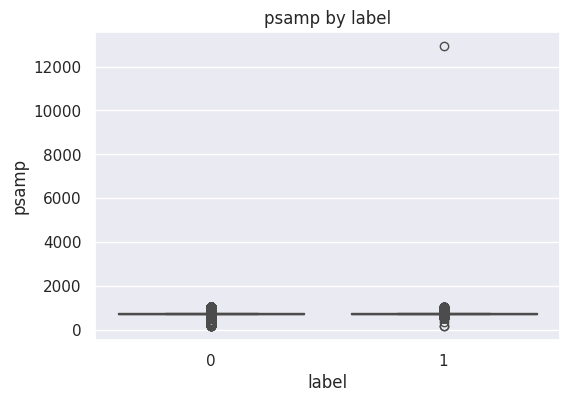

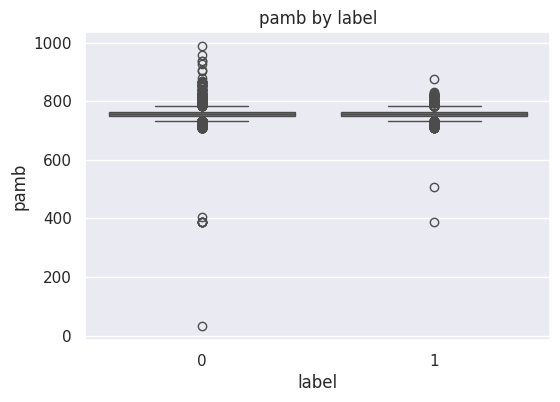

In [46]:
import seaborn as sns

for c in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=c, data=df_mhd_ch4_v3)
    plt.title(f"{c} by label")
    plt.show()

Attempt to plot data without the extreme value of pflow(>50000) and psamp(>10000)

Text(0.5, 1.0, 'boxplot: psamp <= 10000 by label')

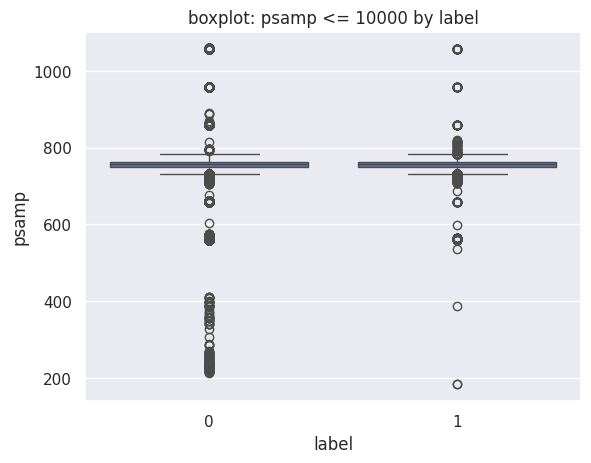

In [47]:
sns.boxplot(x='label', y='psamp', data=df_mhd_ch4_v3[df_mhd_ch4_v3['psamp']<=10000])
plt.title('boxplot: psamp <= 10000 by label')

drop extreme values from pflow and psamp

In [48]:
df_mhd_ch4_drop = df_mhd_ch4_v3[(df_mhd_ch4_v3['psamp']<=10000) & (df_mhd_ch4_v3['pflow']<=90000)]

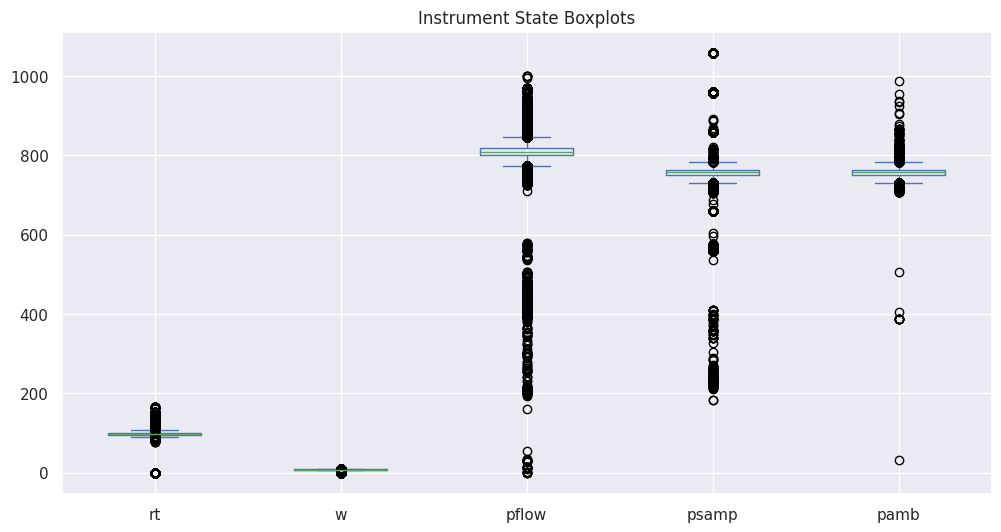

In [49]:
df_mhd_ch4_drop[cols].plot(kind='box', figsize=(12,6))
plt.title("Instrument State Boxplots")
plt.show()

# explore sample and port (boxplot)

Text(0.5, 1.0, 'sample vs. ch4_c')

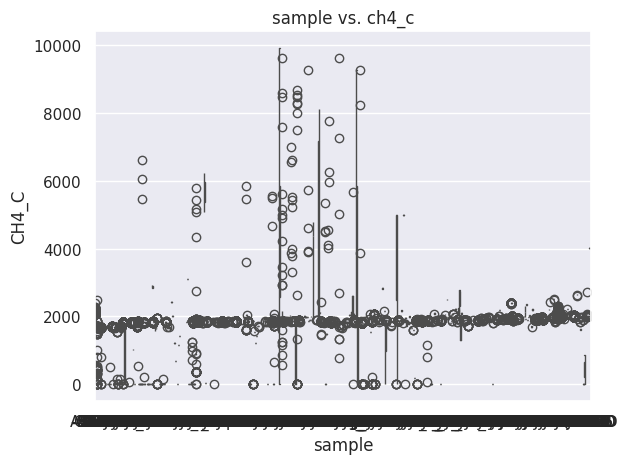

In [50]:
sns.boxplot(x='sample', y='CH4_C', data=df_mhd_ch4_v3)
plt.title('sample vs. ch4_c')

Text(0.5, 1.0, 'Port vs. rt')

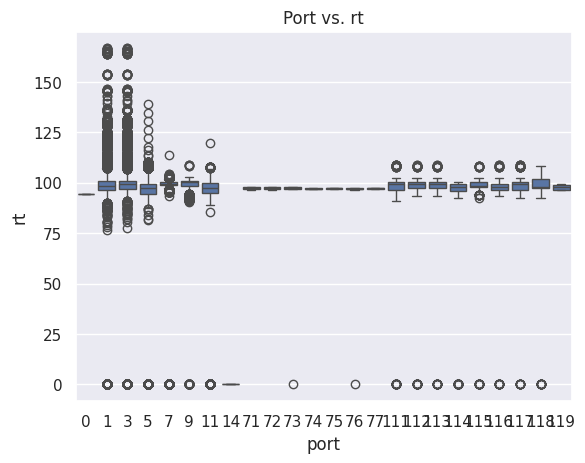

In [51]:
sns.boxplot(x='port', y='rt', data=df_mhd_ch4_v3)
plt.title('Port vs. rt')

Text(0.5, 1.0, 'Port vs. W')

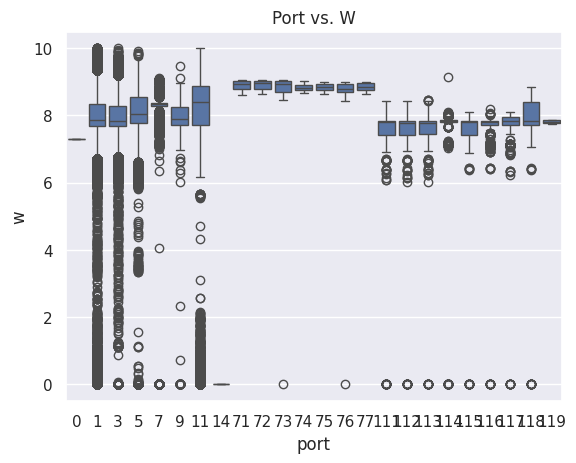

In [52]:
sns.boxplot(x='port', y='w', data=df_mhd_ch4_v3)
plt.title('Port vs. W')


# Explore CH4_C related values

In [53]:
cols = ["CH4_C", "CH4_C_ht", "CH4_C_a", "CH4_area", "CH4_skew"]
df_mhd_ch4_v3[cols].describe()

,CH4_C,CH4_C_ht,CH4_C_a,CH4_area,CH4_skew
count,758120.000000,7.652120e+05,7.669620e+05,8.163650e+05,816365.000000
mean,1889.199695,1.896758e+03,1.899731e+03,1.350951e+06,1.045182
std,158.918317,1.854878e+03,4.166073e+03,2.814009e+05,0.165004
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1848.340000,1.847980e+03,1.848330e+03,1.237542e+06,1.040000
50%,1878.640000,1.879360e+03,1.878350e+03,1.363757e+06,1.070000
75%,1932.750000,1.933160e+03,1.933100e+03,1.484501e+06,1.100000
max,9913.360000,1.328418e+06,3.601524e+06,9.999999e+06,9.940000


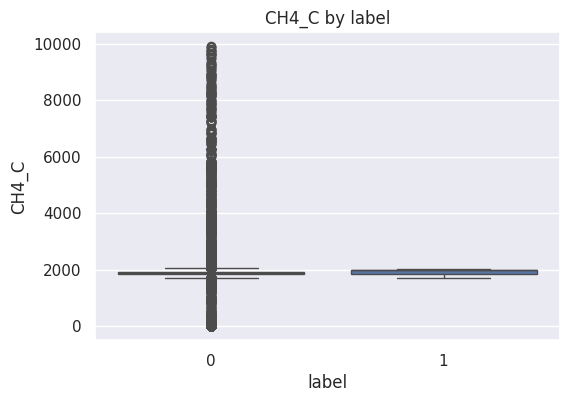

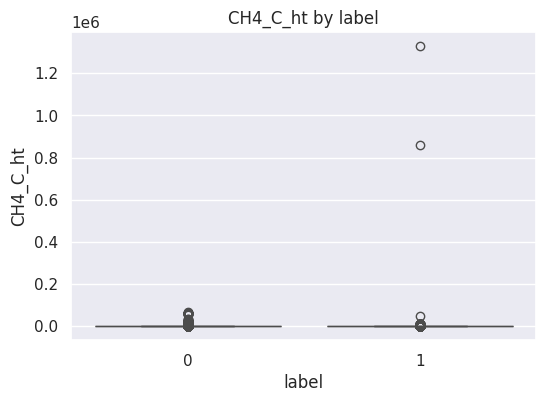

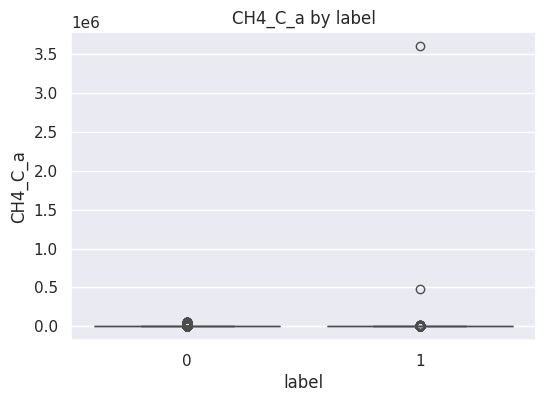

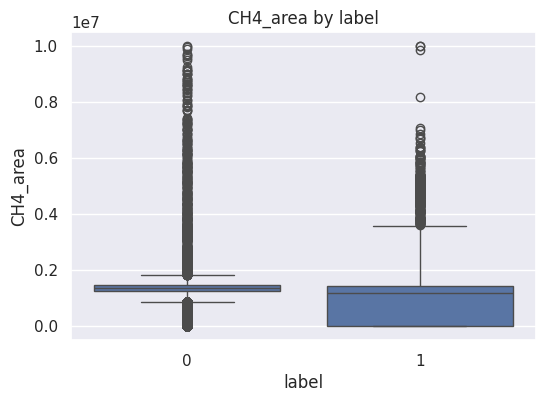

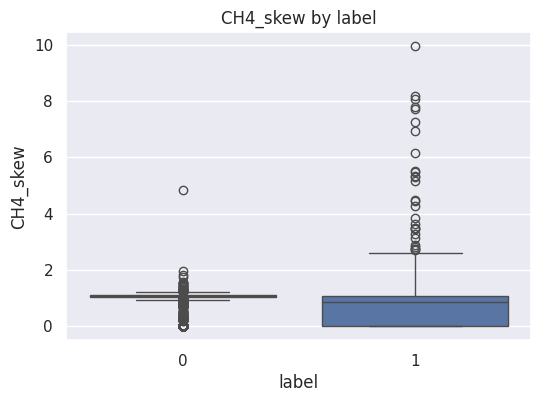

In [54]:
for c in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=c, data=df_mhd_ch4_v3)
    plt.title(f'{c} by label')
    plt.show()

**ch4_boxplot**
skew can be an potential important QC feature(much obvious difference between 0 and 1)

C_ht : label 1, 2 obvious extreme values(0ver 0.8*1e6)

C_a : label 1, 2 obvious extreme values(0ver 0.3*1e6)


In [57]:
df_mhd_ch4_raw[df_mhd_ch4_raw['CH4_C_ht']>0.8*1e6].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
377766,90121,112300,tank,499310,J-116,11,0,40.0,19.52,NaN,773.8,737.68,NaN,737.2,90.4,4.72,999999.0,9999999.0,5.48,79.4,471.8,10400.0,38773.0,54.4332,907.0630,NaN,454.666,908.040,4.1867,54.4332,907.0630,NaN,858205.0,3601524.0,NaN,4.297,NaN,1888.518,F,F,NaN,NaN
706587,211201,105500,labair,labair,J-246,9,0,40.0,22.73,NaN,415.3,727.16,NaN,755.4,97.2,2.33,999999.0,5039744.0,2.05,81.2,163.6,24715.0,30803.0,92.2398,50.8062,NaN,666.474,41.471,0.3033,92.2398,50.8062,NaN,1328418.0,481301.0,NaN,4.826,NaN,1919.014,F,F,NaN,NaN


In [58]:
df_mhd_ch4_raw[df_mhd_ch4_raw['CH4_C_a']>0.3*1e6].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,temp,pflow,psamp,ploop,pamb,rt,w,CH4_ht.1,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
377766,90121,112300,tank,499310,J-116,11,0,40.0,19.52,NaN,773.8,737.68,NaN,737.2,90.4,4.72,999999.0,9999999.0,5.48,79.4,471.8,10400.0,38773.0,54.4332,907.0630,NaN,454.666,908.040,4.1867,54.4332,907.0630,NaN,858205.0,3601524.0,NaN,4.297,NaN,1888.518,F,F,NaN,NaN
706587,211201,105500,labair,labair,J-246,9,0,40.0,22.73,NaN,415.3,727.16,NaN,755.4,97.2,2.33,999999.0,5039744.0,2.05,81.2,163.6,24715.0,30803.0,92.2398,50.8062,NaN,666.474,41.471,0.3033,92.2398,50.8062,NaN,1328418.0,481301.0,NaN,4.826,NaN,1919.014,F,F,NaN,NaN


C_ht : label 1, 2 obvious extreme values(0ver 0.8*1e6)

C_a : label 1, 2 obvious extreme values(0ver 0.3*1e6)
--------------------------
They are the same data point
-------
but no problem with rt and w
----------- guess
rt, w -> if the peak exists
C_a, C_ht -> if the fitted peak is right?


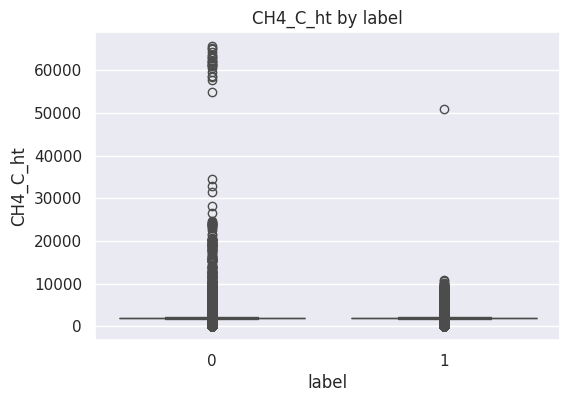

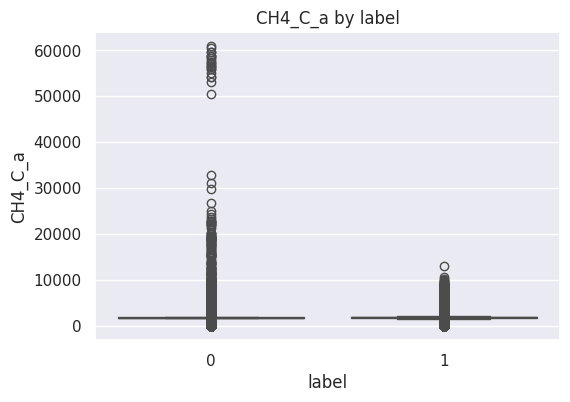

In [59]:
# C_a, C_ht without extreme values, in order to see the boxplot
df_mhd_ch4_dropv1 = df_mhd_ch4_v3[(df_mhd_ch4_v3['CH4_C_ht']<0.8*1e6)&(df_mhd_ch4_v3['CH4_C_a']<0.3*1e6)]
for c in ['CH4_C_ht', 'CH4_C_a']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=c, data=df_mhd_ch4_dropv1)
    plt.title(f'{c} by label')
    plt.show()

label 1 data distribution in ht and a are almost the same
that potentially means ht and area are highly related.

**tac_ch4**

In [54]:
import pandas as pd
df_tac_ch4 = pd.read_csv("../data/processed/tac_ch4_formatted_v1.csv")
df_tac_ch4.head(20)

,date,time,type,sample,standard,port,dry,wet,stdev,std_rep,std_stdev,target_error,Cdrift,C,N,Nfiltered,time.1,h2o,stdev.1,press,press_stdev,temp,temp_stdev,temp.1,temp.2,temp.3,valve,CH4_flag
0,120111,162730,unknown,-,USN-20112109,0,1944.517,1945.109,42.208,NaN,NaN,NaN,1955.510,1955.527,0,100.0,3.733,-0.02232,0.00175,140.00525,0.01396,44.90277,0.01251,32.14167,44.77072,NaN,31442.617,x
1,120111,162830,unknown,-,USN-20112109,0,1972.043,1972.643,57.714,NaN,NaN,NaN,1983.192,1983.217,0,100.0,3.733,-0.02232,0.00170,140.00435,0.01518,44.92952,0.00415,32.36250,44.91882,NaN,31543.971,x
2,120111,162930,unknown,-,USN-20112109,0,1940.176,1940.768,65.419,NaN,NaN,NaN,1951.144,1951.159,0,100.0,3.733,-0.02243,0.00221,140.00513,0.01176,44.93352,0.00128,32.59792,44.99702,NaN,31626.549,x
3,120111,163030,unknown,-,USN-20112109,0,2021.915,2022.526,80.016,NaN,NaN,NaN,2033.346,2033.386,0,100.0,3.733,-0.02217,0.00256,140.00745,0.01437,44.92616,0.00253,32.81506,45.02549,NaN,31687.379,x
4,120111,163130,unknown,-,USN-20112109,0,1976.217,1976.825,57.151,NaN,NaN,NaN,1987.390,1987.416,0,100.0,3.625,-0.02259,0.00192,140.00314,0.01321,44.91914,0.00165,32.98813,45.02443,NaN,31726.805,x
5,120111,163230,unknown,-,USN-20112109,0,1977.023,1977.629,107.839,NaN,NaN,NaN,1988.200,1988.226,0,100.0,3.733,-0.02248,0.00258,139.99792,0.01910,44.91655,0.00026,33.13750,45.00900,NaN,31758.904,F
6,120111,163330,unknown,-,USN-20112109,0,1974.220,1974.855,94.284,NaN,NaN,NaN,1985.381,1985.406,0,100.0,3.500,-0.02362,0.00115,140.00032,0.01554,44.91776,0.00100,33.26172,44.98967,NaN,31785.496,F
7,120111,163430,unknown,-,USN-20112109,0,1904.261,1904.902,51.648,NaN,NaN,NaN,1915.027,1915.031,0,100.0,3.500,-0.02471,0.00000,140.00146,0.01652,44.92261,0.00181,33.35547,44.97134,NaN,31807.650,F
8,120111,163530,unknown,-,USN-20112109,0,1929.363,1930.012,59.736,NaN,NaN,NaN,1940.270,1940.282,0,100.0,3.500,-0.02471,0.00000,139.99977,0.01241,44.92999,0.00249,33.42248,44.95708,NaN,31827.049,F
9,120111,163630,unknown,-,USN-20112109,0,1970.042,1970.705,71.395,NaN,NaN,NaN,1981.180,1981.204,0,100.0,3.471,-0.02471,0.00000,140.00076,0.01586,44.93916,0.00306,33.47794,44.94679,NaN,31844.387,F


In [55]:
df_tac_ch4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6828990 entries, 0 to 6828989
Data columns (total 28 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          int64  
 1   time          int64  
 2   type          object 
 3   sample        object 
 4   standard      object 
 5   port          int64  
 6   dry           float64
 7   wet           float64
 8   stdev         float64
 9   std_rep       float64
 10  std_stdev     float64
 11  target_error  float64
 12  Cdrift        float64
 13  C             float64
 14  N             int64  
 15  Nfiltered     float64
 16  time.1        float64
 17  h2o           float64
 18  stdev.1       float64
 19  press         float64
 20  press_stdev   float64
 21  temp          float64
 22  temp_stdev    float64
 23  temp.1        float64
 24  temp.2        float64
 25  temp.3        float64
 26  valve         float64
 27  CH4_flag      object 
dtypes: float64(20), int64(4), object(4)
memory usage: 1.4+ GB


In [56]:
df_tac_ch4.iloc[[1162387]]

,date,time,type,sample,standard,port,dry,wet,stdev,std_rep,std_stdev,target_error,Cdrift,C,N,Nfiltered,time.1,h2o,stdev.1,press,press_stdev,temp,temp_stdev,temp.1,temp.2,temp.3,valve,CH4_flag
1162387,140529,214630,air,54m,USN-20112109,8,1959.93,1955.037,0.501,0.207,0.2,0.194,1968.97,1968.991,0,100.0,5.4,0.18451,0.00038,140.00331,0.01364,44.9998,0.00027,35.93707,45.01207,NaN,31757.213,x


**tac_co2.csv**

In [57]:
df_tac_co2 = pd.read_csv("../data/processed/tac_co2_formatted_v1.csv")
df_tac_co2.head(20)

,date,time,type,sample,standard,port,dry,wet,stdev,std_rep,std_stdev,target_error,Cdrift,C,N,Nfiltered,time.1,h2o,stdev.1,press,press_stdev,temp,temp_stdev,temp.1,temp.2,temp.3,valve,CH4_flag
0,120111,162730,unknown,-,USN-20112109,0,403.464,403.606,1.063,NaN,NaN,NaN,406.303,406.300,0,100.0,3.733,-0.02232,0.00175,140.00525,0.01396,44.90277,0.01251,32.14167,44.77072,NaN,31442.617,x
1,120111,162830,unknown,-,USN-20112109,0,402.944,403.085,1.308,NaN,NaN,NaN,405.779,405.776,0,100.0,3.733,-0.02232,0.00170,140.00435,0.01518,44.92952,0.00415,32.36250,44.91882,NaN,31543.971,x
2,120111,162930,unknown,-,USN-20112109,0,400.992,401.133,1.802,NaN,NaN,NaN,403.813,403.811,0,100.0,3.733,-0.02243,0.00221,140.00513,0.01176,44.93352,0.00128,32.59792,44.99702,NaN,31626.549,x
3,120111,163030,unknown,-,USN-20112109,0,401.753,401.893,1.516,NaN,NaN,NaN,404.580,404.577,0,100.0,3.733,-0.02217,0.00256,140.00745,0.01437,44.92616,0.00253,32.81506,45.02549,NaN,31687.379,x
4,120111,163130,unknown,-,USN-20112109,0,401.479,401.622,0.743,NaN,NaN,NaN,404.304,404.301,0,100.0,3.625,-0.02259,0.00192,140.00314,0.01321,44.91914,0.00165,32.98813,45.02443,NaN,31726.805,x
5,120111,163230,unknown,-,USN-20112109,0,401.215,401.356,0.619,NaN,NaN,NaN,404.038,404.035,0,100.0,3.733,-0.02248,0.00258,139.99792,0.01910,44.91655,0.00026,33.13750,45.00900,NaN,31758.904,F
6,120111,163330,unknown,-,USN-20112109,0,401.416,401.565,0.727,NaN,NaN,NaN,404.241,404.238,0,100.0,3.500,-0.02362,0.00115,140.00032,0.01554,44.91776,0.00100,33.26172,44.98967,NaN,31785.496,F
7,120111,163430,unknown,-,USN-20112109,0,404.622,404.779,2.342,NaN,NaN,NaN,407.469,407.466,0,100.0,3.500,-0.02471,0.00000,140.00146,0.01652,44.92261,0.00181,33.35547,44.97134,NaN,31807.650,F
8,120111,163530,unknown,-,USN-20112109,0,401.350,401.506,2.698,NaN,NaN,NaN,404.174,404.171,0,100.0,3.500,-0.02471,0.00000,139.99977,0.01241,44.92999,0.00249,33.42248,44.95708,NaN,31827.049,F
9,120111,163630,unknown,-,USN-20112109,0,410.890,411.049,3.356,NaN,NaN,NaN,413.781,413.777,0,100.0,3.471,-0.02471,0.00000,140.00076,0.01586,44.93916,0.00306,33.47794,44.94679,NaN,31844.387,F


In [58]:
df_tac_co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6828990 entries, 0 to 6828989
Data columns (total 28 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          int64  
 1   time          int64  
 2   type          object 
 3   sample        object 
 4   standard      object 
 5   port          int64  
 6   dry           float64
 7   wet           float64
 8   stdev         float64
 9   std_rep       float64
 10  std_stdev     float64
 11  target_error  float64
 12  Cdrift        float64
 13  C             float64
 14  N             int64  
 15  Nfiltered     float64
 16  time.1        float64
 17  h2o           float64
 18  stdev.1       float64
 19  press         float64
 20  press_stdev   float64
 21  temp          float64
 22  temp_stdev    float64
 23  temp.1        float64
 24  temp.2        float64
 25  temp.3        float64
 26  valve         float64
 27  CH4_flag      object 
dtypes: float64(20), int64(4), object(4)
memory usage: 1.4+ GB


In [59]:
pd.set_option('display.max_columns', None)
df_tac_co2.iloc[[6785952]]

,date,time,type,sample,standard,port,dry,wet,stdev,std_rep,std_stdev,target_error,Cdrift,C,N,Nfiltered,time.1,h2o,stdev.1,press,press_stdev,temp,temp_stdev,temp.1,temp.2,temp.3,valve,CH4_flag
6785952,250620,232430,air,185m,CFF-011,10,421.179,420.94,0.043,0.018,0.019,0.069,423.636,423.635,0,100.0,3.625,0.03656,0.00063,140.00044,0.0164,45.001,0.0,31.1365,45.074,45.001,33873.469,x
